<a href="https://colab.research.google.com/github/jaitrasaketh/IIIT-Hyderabad-AI-ML-Program/blob/main/AIML_III_Module_4_Lab_2_Introduction_to_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Students Internship Batch of 2024**
# Module 4: Perceptron and Gradient Descent
## Lab 2: Introduction to Gradient Descent

Gradient descent is a very important algorithm to understand, as it underpins many of the more advanced algorithms used in Machine Learning and Deep Learning.

A brief overview of the algorithm is


*   start with a random initialization of the solution.
*   incrementally change the solution by moving in the direction of negative gradient of the objective function.
*   repeat the previous step until some convergence criteria is met.

The key equation for change in weight is:
$$w^{k+1} \leftarrow w^k - \eta \Delta J$$



In [ ]:
# Importing the required libraries

import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)
np.random.seed(42)

We can start be choosing coefficients for a second degree polynomial equation $(a x^2 + bx + c)$ that will distribute the data we will try to model.

Let's define some random x data (inputs) we hope to predict y (outputs) of.

In [ ]:
def eval_2nd_degree(coeffs, x):
    """
    Function to return the output of evaluating a second degree polynomial,
    given a specific x value.

    Args:
        coeffs: List containing the coefficients a, b, and c for the polynomial.
        x: The input x value to the polynomial.

    Returns:
        y: The corresponding output y value for the second degree polynomial.

    """

    a = coeffs[0] * (x * x)
    b = coeffs[1] * x
    c = coeffs[2]
    y = a + b + c
    return y

hundred_xs = np.random.uniform(-10, 10, 100)
coeffs = [1, 0, 0]

xs = []
ys = []
for x in hundred_xs:
    y  = eval_2nd_degree(coeffs, x)
    xs.append(x)
    ys.append(y)

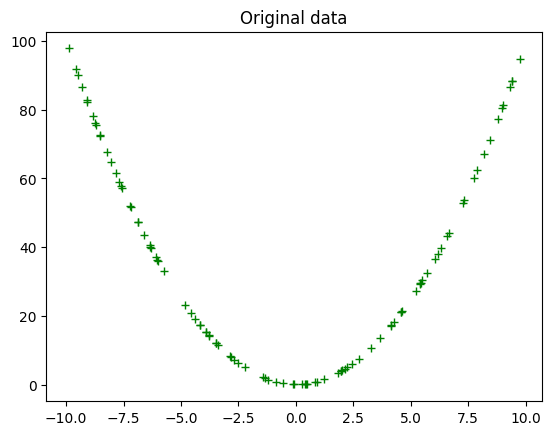

In [ ]:
plt.plot(xs, ys, 'g+')
plt.title('Original data')
plt.show()

This is good, but we could improve on this by making things more realistic. You can add noise or **jitter** to the values so they can resemble real-world data.


In [ ]:
def eval_2nd_degree_jitter(coeffs, x, j):
    """
    Function to return the noisy output of evaluating a second degree polynomial,
    given a specific x value. Output values can be within [y − j, y + j].

    Args:
        coeffs: List containing the coefficients a, b, and c for the polynomial.
        x: The input x value to the polynomial.
        j: Jitter parameter, to introduce noise to output y.

    Returns:
        y: The corresponding jittered output y value for the second degree polynomial.

    """

    a = coeffs[0] * (x * x)
    b = coeffs[1] * x
    c = coeffs[2]
    y = a + b + c

    interval = [y - j, y + j]
    interval_min = interval[0]
    interval_max = interval[1]
    jit_val = random.random() * interval_max      # Generate a random number in range 0 to interval max

    while interval_min > jit_val:                 # While the random jitter value is less than the interval min,
        jit_val = random.random() * interval_max  # it is not in the right range. Re-roll the generator until it
                                                  # give a number greater than the interval min.

    return jit_val

xs = []
ys = []
for x in hundred_xs:
    y  = eval_2nd_degree_jitter(coeffs, x, 0.1)
    xs.append(x)
    ys.append(y)


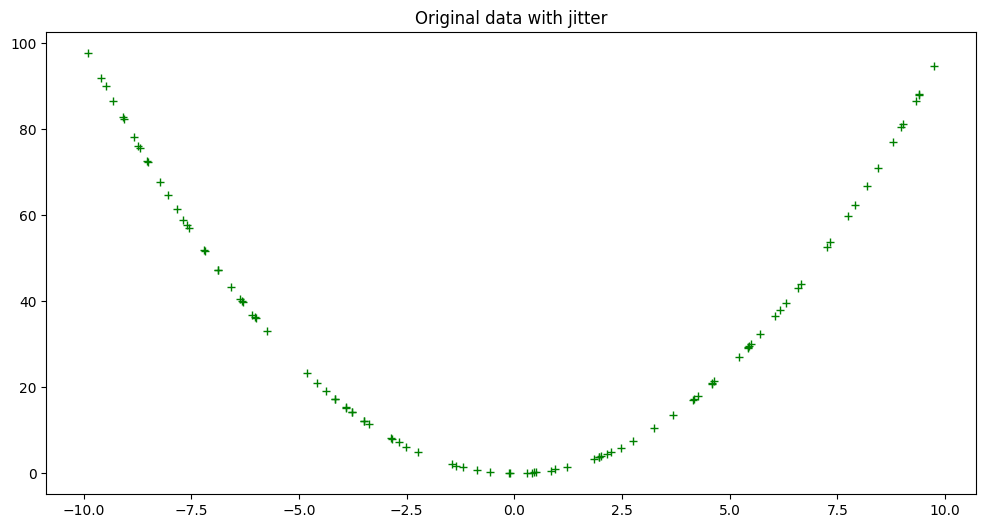

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+')
plt.title('Original data with jitter')
plt.show()

We will now build our predictive model, and optimize it with gradient descent and we will try to get as close to these values as possible.

To get a quantifiable measure of how incorrect it is, we calculate the Mean Squared Error loss for the model. This is the mean value of the sum of the squared differences between the actual and predicted outputs.

$$ E = \frac{1}{n} \sum_{i=0}^n (y_i - \bar{y_i})^2 $$

In [ ]:
def loss_mse(ys, y_bar):
    """
    Calculates MSE loss.

    Args:
        ys: training data labels
        y_bar: prediction labels

    Returns: Calculated MSE loss.
    """

    return sum((ys - y_bar) * (ys - y_bar)) / len(ys)

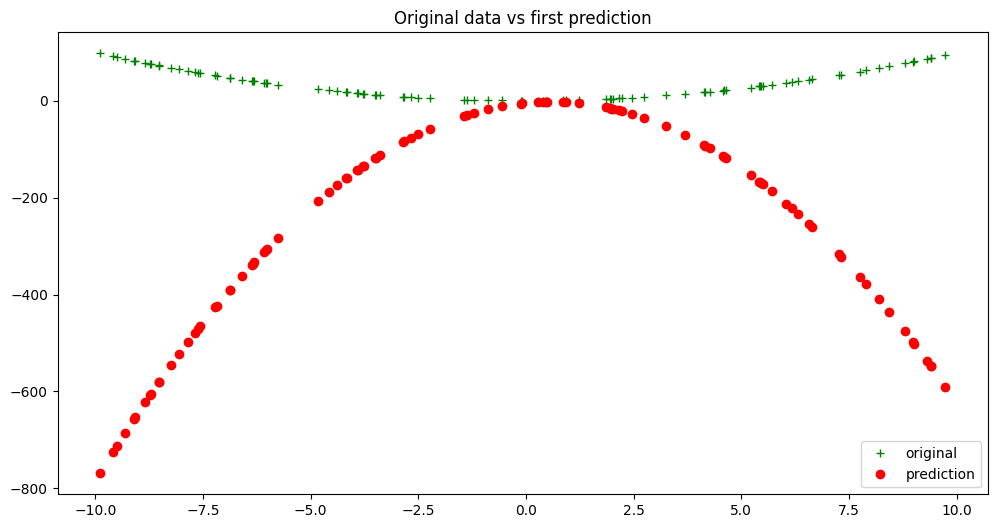

In [ ]:
rand_coeffs = (random.randrange(-10, 10), random.randrange(-10, 10), random.randrange(-10, 10))
y_bar = eval_2nd_degree(rand_coeffs, hundred_xs)
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+', label = 'original')
plt.plot(xs, y_bar, 'ro', label = 'prediction')
plt.title('Original data vs first prediction')
plt.legend(loc="lower right")
plt.show()

In [ ]:
initial_model_loss = loss_mse(ys, y_bar)
initial_model_loss

146807.86204726336

We can see that the loss is quite a large number. Let’s now see if we can improve on this fairly high loss metric by optimizing the model with gradient descent.

We wish to improve our model. Therefore we want to alter its coefficients $a$, $b$ and $c$ to decrease the error. Therefore we require knowledge about how each coefficient affects the error. This is achieved by calculating the partial derivative of the loss function with respect to **each** of the individual coefficients.

In [ ]:
def calc_gradient_2nd_poly(rand_coeffs, hundred_xs, ys):
    """
    calculates the gradient for a second degree polynomial.

    Args:
        coeffs: a,b and c, for a 2nd degree polynomial [ y = ax^2 + bx + c ]
        inputs_x: x input datapoints
        outputs_y: actual y output points

    Returns: Calculated gradients for the 2nd degree polynomial, as a tuple of its parts for a,b,c respectively.

    """

    a_s = []
    b_s = []
    c_s = []

    y_bars = eval_2nd_degree(rand_coeffs, hundred_xs)

    for x, y, y_bar in list(zip(hundred_xs, ys, y_bars)):    # take tuple of (x datapoint, actual y label, predicted y label)
        x_squared = x ** 2
        partial_a = x_squared * (y - y_bar)
        a_s.append(partial_a)
        partial_b = x * (y - y_bar)
        b_s.append(partial_b)
        partial_c = (y - y_bar)
        c_s.append(partial_c)

    num = [i for i in y_bars]
    n = len(num)

    gradient_a = (-2 / n) * sum(a_s)
    gradient_b = (-2 / n) * sum(b_s)
    gradient_c = (-2 / n) * sum(c_s)

    return (gradient_a, gradient_b, gradient_c)   # return calculated gradients as a a tuple of its 3 parts

In [ ]:
calc_grad = calc_gradient_2nd_poly(rand_coeffs, hundred_xs, ys)

lr = 0.0001
a_new = rand_coeffs[0] - lr * calc_grad[0]
b_new = rand_coeffs[1] - lr * calc_grad[1]
c_new = rand_coeffs[2] - lr * calc_grad[2]

new_model_coeffs = (a_new, b_new, c_new)
print(f"New model coeffs: {new_model_coeffs}")

# update with these new coeffs:
new_y_bar = eval_2nd_degree(new_model_coeffs, hundred_xs)
updated_model_loss = loss_mse(ys, new_y_bar)

print(f"Now have smaller model loss: {updated_model_loss} vs {initial_model_loss}")

New model coeffs: (-3.4872074852403587, 7.879149056895183, -4.941405407033594)
Now have smaller model loss: 49608.172144854274 vs 146807.86204726336


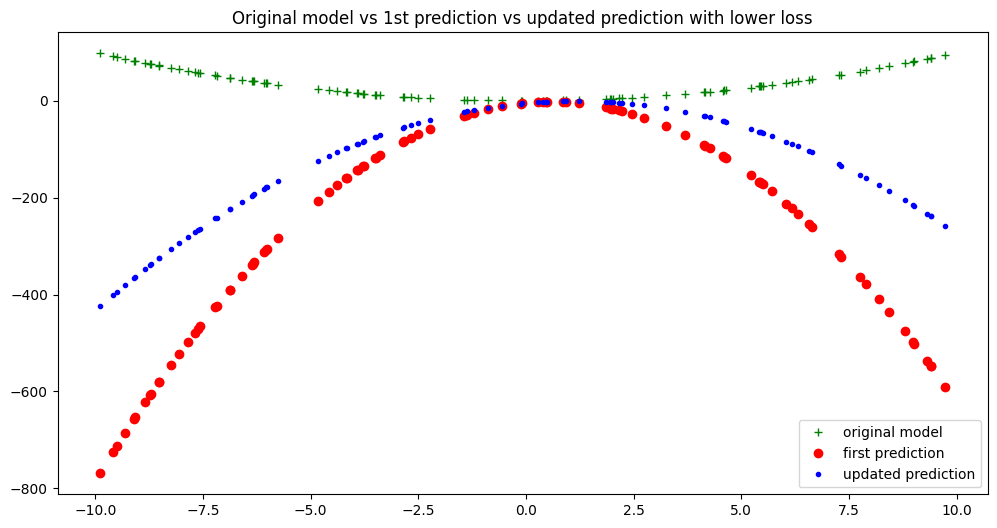

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+', label = 'original model')
plt.plot(xs, y_bar, 'ro', label = 'first prediction')
plt.plot(xs, new_y_bar, 'b.', label = 'updated prediction')
plt.title('Original model vs 1st prediction vs updated prediction with lower loss')
plt.legend(loc="lower right")
plt.show()

We’re almost ready. The last step will be to perform gradient descent iteratively over a number of epochs (cycles or iterations.) With every epoch we hope to see an improvement in the form of lowered loss, and better model-fitting to the original data.

In [ ]:
def calc_gradient_2nd_poly_for_GD(coeffs, inputs_x, outputs_y, lr):
    """
    calculates the gradient for a second degree polynomial.

    Args:
        coeffs: a,b and c, for a 2nd degree polynomial [ y = ax^2 + bx + c ]
        inputs_x: x input datapoints
        outputs_y: actual y output points
        lr: learning rate

    Returns: Calculated gradients for the 2nd degree polynomial, as a tuple of its parts for a,b,c respectively.

    """
    a_s = []
    b_s = []
    c_s = []

    y_bars = eval_2nd_degree(coeffs, inputs_x)

    for x,y,y_bar in list(zip(inputs_x, outputs_y, y_bars)):    # take tuple of (x datapoint, actual y label, predicted y label)
        x_squared = x ** 2
        partial_a = x_squared * (y - y_bar)
        a_s.append(partial_a)
        partial_b = x * (y - y_bar)
        b_s.append(partial_b)
        partial_c = (y - y_bar)
        c_s.append(partial_c)

    num = [i for i in y_bars]
    n = len(num)

    gradient_a = (-2 / n) * sum(a_s)
    gradient_b = (-2 / n) * sum(b_s)
    gradient_c = (-2 / n) * sum(c_s)


    a_new = coeffs[0] - lr * gradient_a
    b_new = coeffs[1] - lr * gradient_b
    c_new = coeffs[2] - lr * gradient_c

    new_model_coeffs = (a_new, b_new, c_new)

    # update with these new coeffs:
    new_y_bar = eval_2nd_degree(new_model_coeffs, inputs_x)

    updated_model_loss = loss_mse(outputs_y, new_y_bar)
    return updated_model_loss, new_model_coeffs, new_y_bar

In [ ]:
def gradient_descent(epochs, lr):
    """
    Perform gradient descent for a second degree polynomial.

    Args:
        epochs: number of iterations to perform of finding new coefficients and updatingt loss.
        lr: specified learning rate

    Returns: Tuple containing (updated_model_loss, new_model_coeffs, new_y_bar predictions, saved loss updates)

    """
    losses = []
    rand_coeffs_to_test = rand_coeffs
    for i in range(epochs):
        loss = calc_gradient_2nd_poly_for_GD(rand_coeffs_to_test, hundred_xs, ys, lr)
        rand_coeffs_to_test = loss[1]
        losses.append(loss[0])
    print(losses)
    return loss[0], loss[1], loss[2], losses  # (updated_model_loss, new_model_coeffs, new_y_bar, saved loss updates)

In [ ]:
GD = gradient_descent(30000, 0.0003)


[13475.624637116503, 2869.715432846906, 1958.273415665309, 1815.4133533665963, 1736.1622571518062, 1664.7307185029726, 1596.5981613153112, 1531.2972754982177, 1468.6853640008349, 1408.6497165327594, 1351.0841647769712, 1295.8870592843532, 1242.960945034913, 1192.2123779132319, 1143.5517588087196, 1096.8931753375862, 1052.154250140267, 1009.2559954258945, 968.1226735021916, 928.6816630441622, 890.8633308653946, 854.6009089655777, 819.8303766371265, 786.4903474227408, 754.5219607243141, 723.8687778717832, 694.476682468427, 666.2937848366366, 639.2703303954412, 613.3586118080115, 588.5128847440168, 564.6892871080927, 541.8457615918065, 519.9419814123638, 498.9392791069297, 478.8005782568453, 459.49032802117404, 440.9744403639862, 423.2202298645435, 406.1963560041051, 389.8727678274495, 374.22065088139925, 359.2123763366603, 344.8214522031347, 331.0224765525732, 317.7910926659628, 305.1039460264636, 292.9386430819466, 281.27371170432554, 270.0885632758611, 259.3634563354952, 249.0794617210

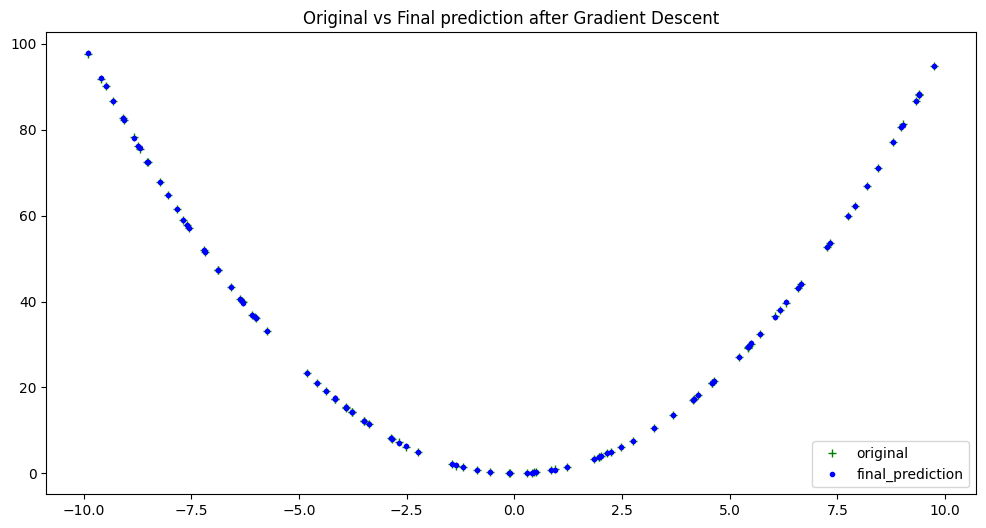

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(xs, ys, 'g+', label = 'original')
plt.plot(xs, GD[2], 'b.', label = 'final_prediction')
plt.title('Original vs Final prediction after Gradient Descent')
plt.legend(loc = "lower right")
plt.show()

This trained model is showing vast improvements after it’s full training cycle. We can examine further by inspecting its final predicted coefficients $a$, $b$ and $c$.

In [ ]:
print(f"Final Coefficients predicted: {GD[1]}")
print(f"Original Coefficients: {coeffs}")

Final Coefficients predicted: (0.9999579417260247, -0.002867610798230069, -0.012778521556486263)
Original Coefficients: [1, 0, 0]


Not too far off! A big improvement over the initial random model. Looking at the plot of the loss reduction over training offers further insights.


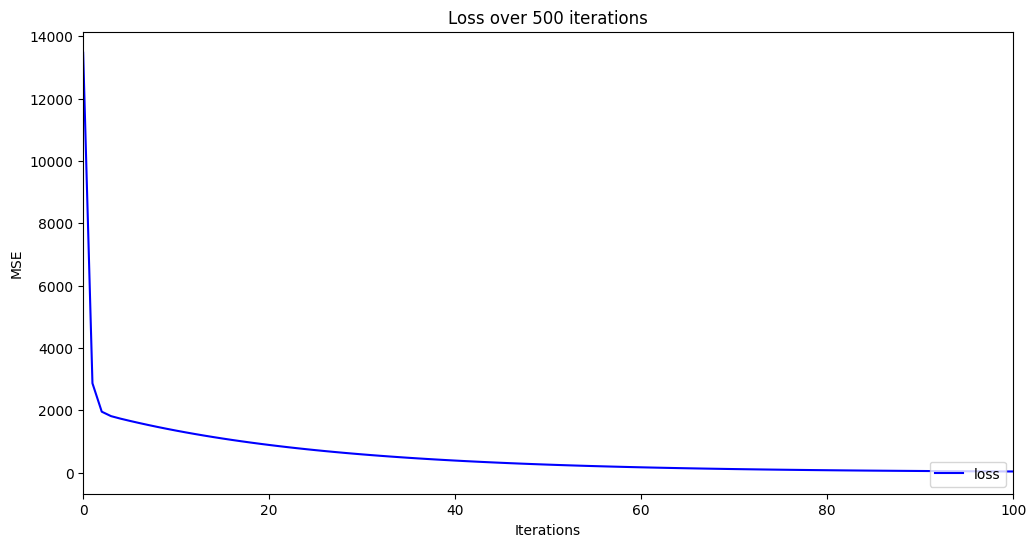

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(GD[3], 'b-', label = 'loss')
# plt.xlim(0,50)
plt.title('Loss over 500 iterations')
plt.legend(loc="lower right")
plt.xlim((0,100))
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.show()

We observe that the model loss reached close to zero, to give us our more accurate coefficients. We can also see there was no major improvement in loss after about 100 epochs. An alternative strategy would be to add some kind of condition to the training step that stops training when a certain minimum loss threshold has been reached. This would prevent excessive training and potential over-fitting for the model.

# Things to try



1.   Change the coefficients array and try a different polynomial instead of our $x^2$.
2.   Increase/decrease the learning rate to see how many iterations will be take to coverge. Does it even converge on a huge learning rate?
3. Take a degree 5 polynomial with 5 roots and try different initializations, instead of random ones. Does it converge on different values for different initializations? Why does initialization not matter in our case of $x^2$?
4. Can you modify the algorithm to find a maxima of a function, instead of a minima?



##1A

In [21]:


hundred_xs = np.random.uniform(-10, 10, 100)
coeffs = [1, -2, 1]

xs = []
ys = []
for x in hundred_xs:
    y  = eval_2nd_degree(coeffs, x)
    xs.append(x)
    ys.append(y)

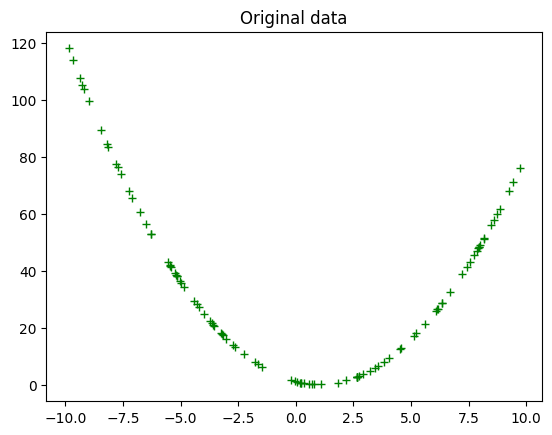

In [22]:
plt.plot(xs, ys, 'g+')
plt.title('Original data')
plt.show()

In [23]:
xs = []
ys = []
for x in hundred_xs:
    y  = eval_2nd_degree_jitter(coeffs, x, 0.1)
    xs.append(x)
    ys.append(y)


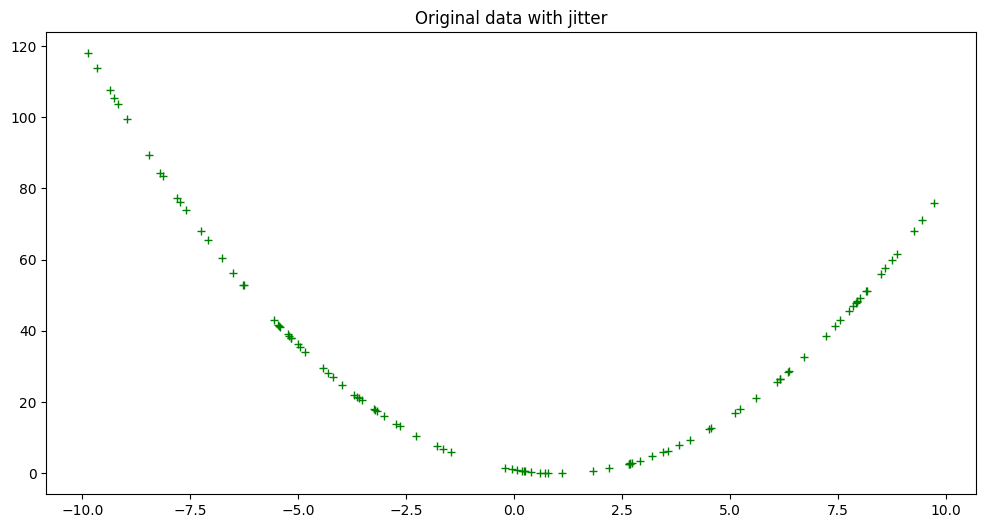

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+')
plt.title('Original data with jitter')
plt.show()

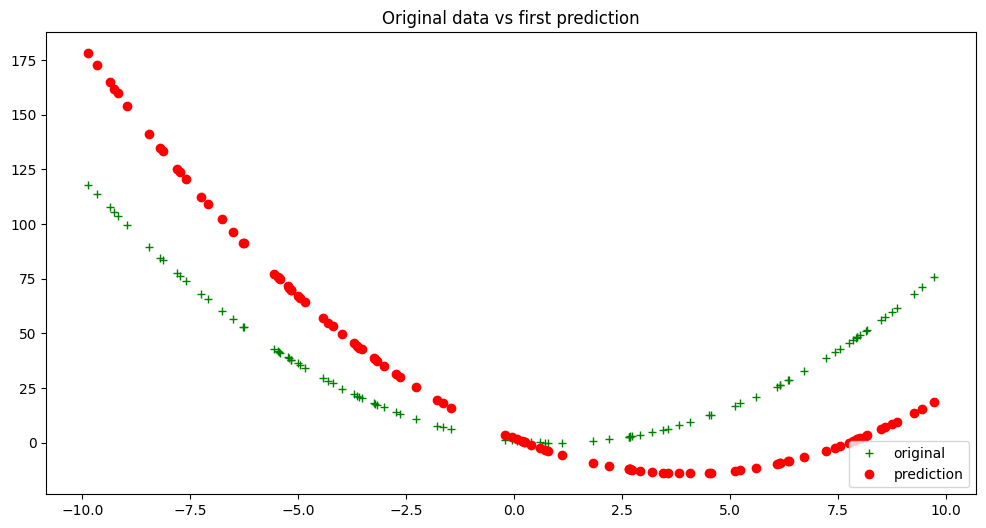

In [25]:
rand_coeffs = (random.randrange(-10, 10), random.randrange(-10, 10), random.randrange(-10, 10))
y_bar = eval_2nd_degree(rand_coeffs, hundred_xs)
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+', label = 'original')
plt.plot(xs, y_bar, 'ro', label = 'prediction')
plt.title('Original data vs first prediction')
plt.legend(loc="lower right")
plt.show()

In [26]:
initial_model_loss = loss_mse(ys, y_bar)
initial_model_loss

1226.901658028014

In [27]:
calc_grad = calc_gradient_2nd_poly(rand_coeffs, hundred_xs, ys)

lr = 0.0001
a_new = rand_coeffs[0] - lr * calc_grad[0]
b_new = rand_coeffs[1] - lr * calc_grad[1]
c_new = rand_coeffs[2] - lr * calc_grad[2]

new_model_coeffs = (a_new, b_new, c_new)
print(f"New model coeffs: {new_model_coeffs}")

# update with these new coeffs:
new_y_bar = eval_2nd_degree(new_model_coeffs, hundred_xs)
updated_model_loss = loss_mse(ys, new_y_bar)

print(f"Now have smaller model loss: {updated_model_loss} vs {initial_model_loss}")

New model coeffs: (1.0030186803743597, -7.959153870059499, 1.999748829417272)
Now have smaller model loss: 1210.202484579264 vs 1226.901658028014


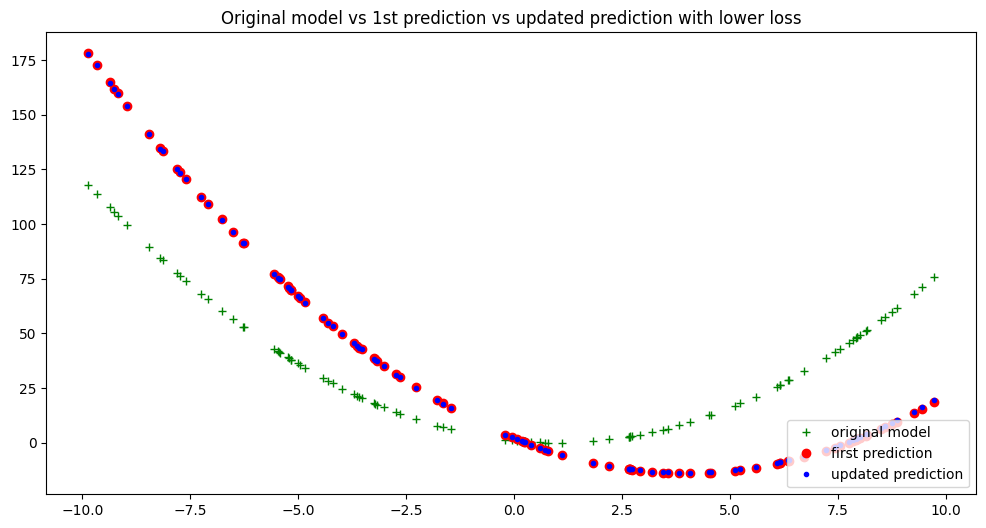

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+', label = 'original model')
plt.plot(xs, y_bar, 'ro', label = 'first prediction')
plt.plot(xs, new_y_bar, 'b.', label = 'updated prediction')
plt.title('Original model vs 1st prediction vs updated prediction with lower loss')
plt.legend(loc="lower right")
plt.show()

In [29]:
GD = gradient_descent(30000, 0.0003)


[1177.2640079280934, 1129.7460138131405, 1084.1502199517945, 1040.3953755601758, 998.4070373640019, 958.1138825258457, 919.4474714636574, 882.3421278215164, 846.7348267920918, 812.5650880621058, 779.7748730836153, 748.3084864928709, 718.112481509192, 689.135569153153, 661.3285311299062, 634.6441362296451, 609.037060103233, 584.4638082767156, 560.8826422739635, 538.2535087219552, 516.5379713182884, 495.69914554535666, 475.7016360203039, 456.5114763743459, 438.0960715593339, 420.42414248356994, 403.46567288283785, 387.19185833639995, 371.5750573413676, 356.588744362343, 342.20746477657855, 328.4067916381349, 315.1632841875919, 302.45444803684416, 290.25869696135237, 278.5553162349497, 267.32442744493034, 256.5469547276543, 246.20459236731745, 236.27977370285447, 226.7556412901594, 217.6160182689442, 208.84538088559876, 200.42883212538524, 192.352076409174, 184.60139531174744, 177.1636242604263, 170.02613017443844, 163.17679000705266, 156.6039701540278, 150.2965066934021, 144.243686423060

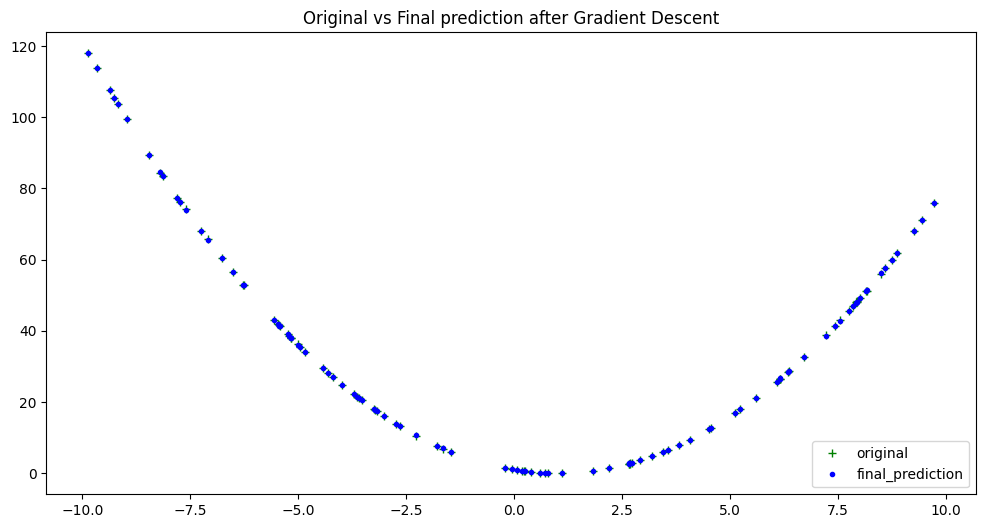

In [30]:
plt.figure(figsize=(12,6))
plt.plot(xs, ys, 'g+', label = 'original')
plt.plot(xs, GD[2], 'b.', label = 'final_prediction')
plt.title('Original vs Final prediction after Gradient Descent')
plt.legend(loc = "lower right")
plt.show()

In [31]:
print(f"Final Coefficients predicted: {GD[1]}")
print(f"Original Coefficients: {coeffs}")

Final Coefficients predicted: (1.0001576785989257, -1.9987498972812225, 0.9992757488994851)
Original Coefficients: [1, -2, 1]


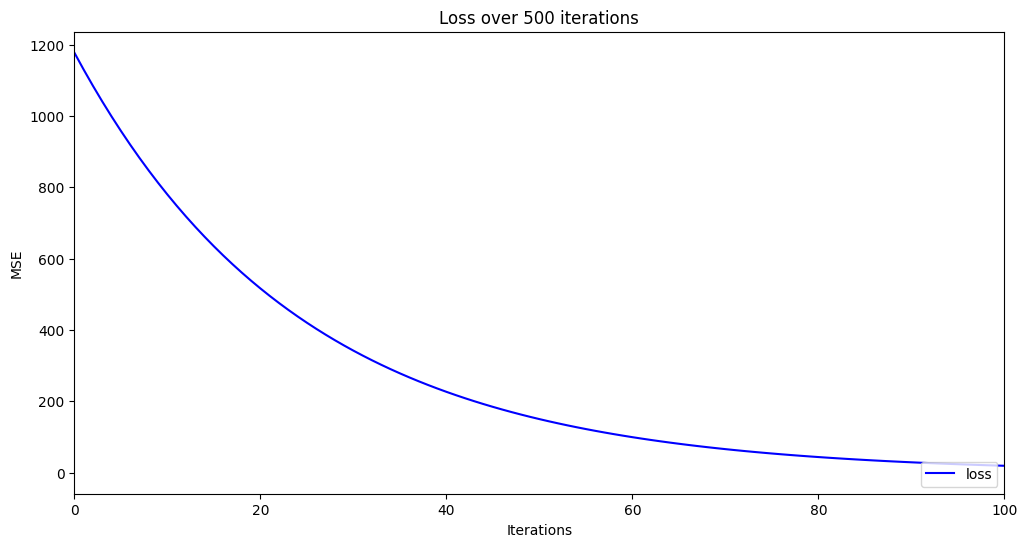

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(GD[3], 'b-', label = 'loss')
# plt.xlim(0,50)
plt.title('Loss over 500 iterations')
plt.legend(loc="lower right")
plt.xlim((0,100))
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.show()

##2A
In case the learning rate is increased

In [35]:
GD = gradient_descent(30000, 0.005)


<ipython-input-6-3e15a3826a00>:12: RuntimeWarning: overflow encountered in scalar add
  return sum((ys - y_bar) * (ys - y_bar)) / len(ys)
<ipython-input-6-3e15a3826a00>:12: RuntimeWarning: overflow encountered in multiply
  return sum((ys - y_bar) * (ys - y_bar)) / len(ys)
<ipython-input-12-bad7532be911>:32: RuntimeWarning: overflow encountered in scalar add
  gradient_a = (-2 / n) * sum(a_s)
<ipython-input-12-bad7532be911>:33: RuntimeWarning: invalid value encountered in scalar add
  gradient_b = (-2 / n) * sum(b_s)
<ipython-input-12-bad7532be911>:37: RuntimeWarning: invalid value encountered in scalar subtract
  a_new = coeffs[0] - lr * gradient_a


[579.7233361750126, 15919.058411478356, 5470857.25661813, 1908036884.0336688, 665466520940.147, 232094937219802.53, 8.09478135857929e+16, 2.8232190683741745e+19, 9.846548726833616e+21, 3.434183443856607e+24, 1.1977410820015656e+27, 4.177364788362137e+29, 1.4569406391142739e+32, 5.081375779813012e+34, 1.7722327953846801e+37, 6.181021079989041e+39, 2.1557563820489003e+42, 7.518637323192569e+44, 2.622277158422537e+47, 9.145723087843721e+49, 3.1897562975316753e+52, 1.1124921605342221e+55, 3.8800418960151355e+57, 1.3532432541010815e+60, 4.719710131611791e+62, 1.6460945701322563e+65, 5.741088453018104e+67, 2.0023209615915063e+70, 6.983500195195646e+72, 2.435637238574096e+75, 8.494778538146296e+77, 2.9627261921153946e+80, 1.033310809696757e+83, 3.603880886049095e+85, 1.2569265044891518e+88, 4.383785945321047e+90, 1.5289342014635036e+93, 5.3324679205650503e+95, 1.8598062687483236e+98, 6.4864513182276056e+100, 2.262281368266012e+103, 7.890164803706549e+105, 2.7518548975791853e+108, 9.5976517166

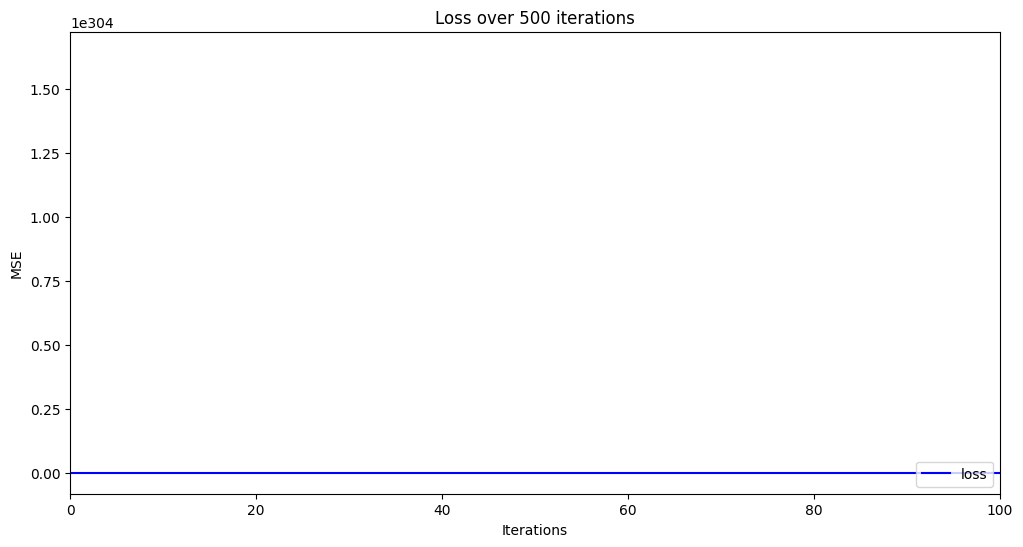

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(GD[3], 'b-', label = 'loss')
# plt.xlim(0,50)
plt.title('Loss over 500 iterations')
plt.legend(loc="lower right")
plt.xlim((0,100))
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.show()

[1225.2248426294439, 1223.5510603704465, 1221.8802489489995, 1220.2123506364842, 1218.547311925152, 1216.8850832027904, 1215.2256184524822, 1213.5688749755375, 1211.9148131357952, 1210.2633961236559, 1208.6145897383174, 1206.9683621868137, 1205.3246838985528, 1203.6835273541742, 1202.0448669275975, 1200.408678740262, 1198.7749405266175, 1197.1436315099784, 1195.5147322879775, 1193.8882247268284, 1192.2640918637749, 1190.6423178170435, 1189.0228877027535, 1187.4057875582416, 1185.7910042712838, 1184.1785255148034, 1182.5683396865911, 1180.960435853694, 1179.3548037010844, 1177.75143348429, 1176.1503159856852, 1174.5514424741425, 1172.9548046678085, 1171.3603946997416, 1169.7682050862097, 1168.1782286974249, 1166.5904587305365, 1165.0048886847203, 1163.4215123381673, 1161.8403237268672, 1160.2613171250161, 1158.6844870269447, 1157.1098281304287, 1155.537335321299, 1153.967003659232, 1152.3988283646331, 1150.8328048065405, 1149.2689284914532, 1147.7071950530271, 1146.1476002425616, 1144.5

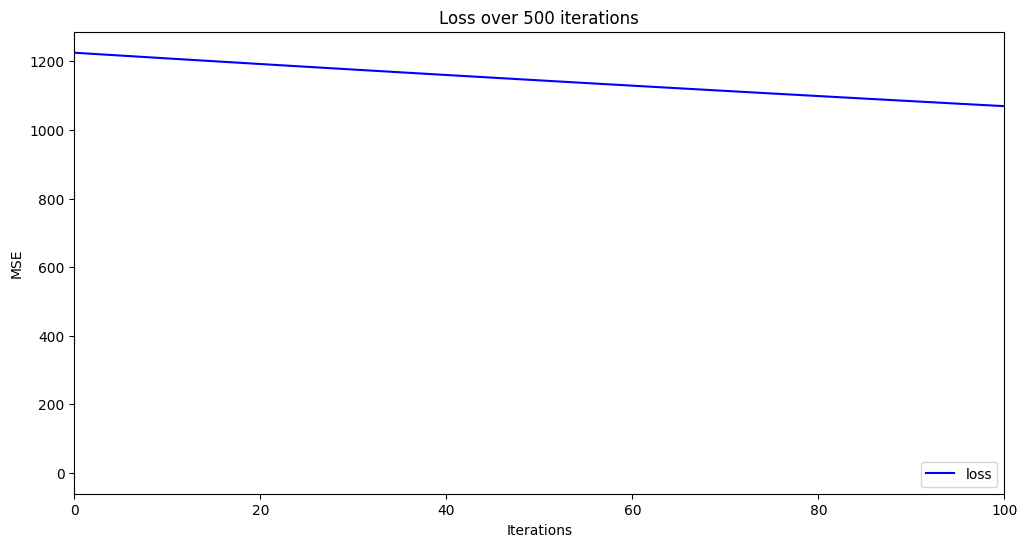

In [39]:
GD = gradient_descent(30000, 0.00001)


plt.figure(figsize=(12, 6))
plt.plot(GD[3], 'b-', label = 'loss')
# plt.xlim(0,50)
plt.title('Loss over 500 iterations')
plt.legend(loc="lower right")
plt.xlim((0,100))
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.show()

##3A



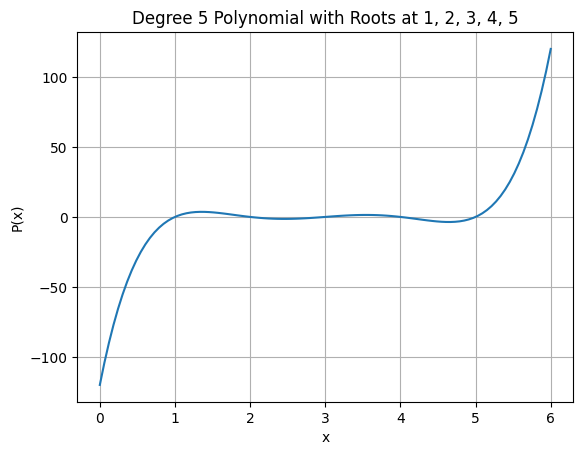

In [42]:
import numpy as np

# Define the roots of the polynomial
roots = [1, 2, 3, 4, 5]

# Function to evaluate the polynomial given the roots
def eval_polynomial(x, roots):
    y = 1
    for r in roots:
        y *= (x - r)
    return y

# Generate some data points
xs = np.linspace(0, 6, 100)  # x values between 0 and 6
ys = [eval_polynomial(x, roots) for x in xs]

# Plot the polynomial
import matplotlib.pyplot as plt
plt.plot(xs, ys)
plt.title("Degree 5 Polynomial with Roots at 1, 2, 3, 4, 5")
plt.xlabel("x")
plt.ylabel("P(x)")
plt.grid(True)
plt.show()


In [43]:
def eval_5th_degree(coeffs, x):
    ##ax^5+bx^4+cx^3+dx^2+ex+f

    a = coeffs[0] * (x*x*x*x*x)
    b = coeffs[1] * (x*x*x*x)
    c = coeffs[2]*(x*x*x)
    d = coeffs[3] * (x * x)
    e = coeffs[4] * (x)
    f=  coeffs[5]
    y = a+b+ c+d+e+f
    return y

hundred_xs = np.random.uniform(-10, 10, 100)
coeffs = [1, 2, 3, 4, 5, 6]

xs = []
ys = []
for x in hundred_xs:
    y  = eval_5th_degree(coeffs, x)
    xs.append(x)
    ys.append(y)

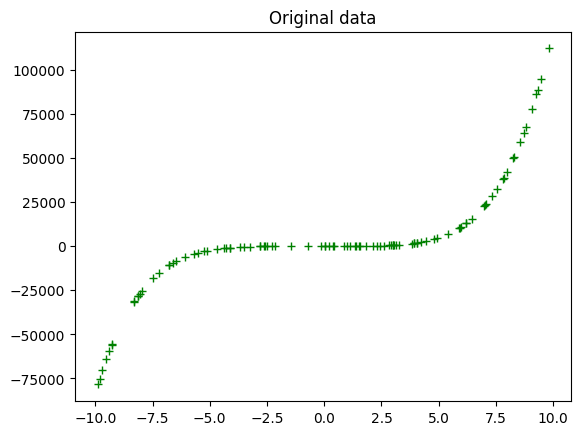

In [44]:
plt.plot(xs, ys, 'g+')
plt.title('Original data')
plt.show()

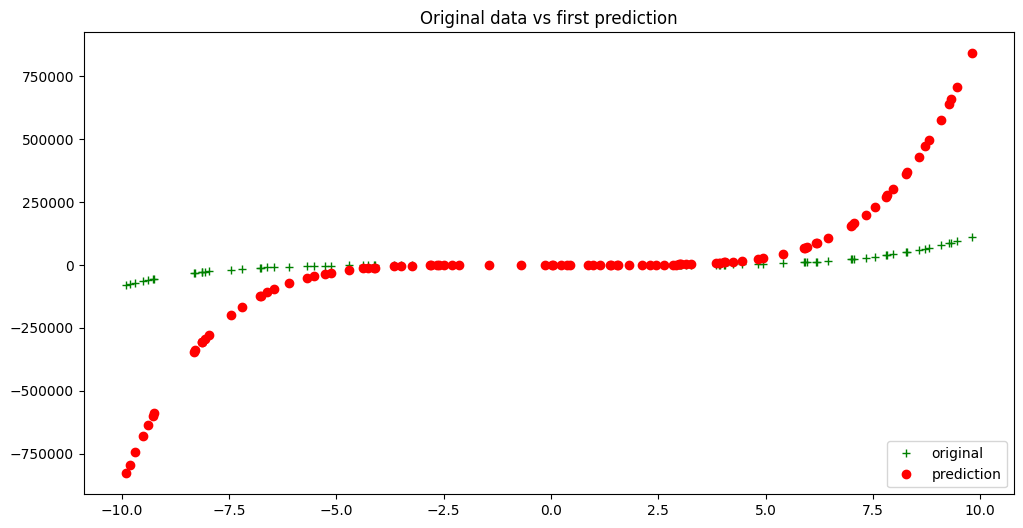

In [48]:
rand_coeffs = [random.randrange(-10, 10) for _ in range(6)]
y_bar = eval_5th_degree(rand_coeffs, hundred_xs)
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+', label = 'original')
plt.plot(xs, y_bar, 'ro', label = 'prediction')
plt.title('Original data vs first prediction')
plt.legend(loc="lower right")
plt.show()

In [49]:
initial_model_loss = loss_mse(ys, y_bar)
initial_model_loss

62258109635.839775

In [51]:
def calc_gradient_5th_poly(coeffs, inputs_x, outputs_y):



    gradients = [0] * len(coeffs)
    y_bars = eval_5th_degree(coeffs, inputs_x)

    for x, y, y_bar in zip(inputs_x, outputs_y, y_bars):
        error = y - y_bar
        for i in range(len(coeffs)):
            gradients[i] += (-2 / len(inputs_x)) * error * (x ** (5 - i))

    return tuple(gradients)


In [52]:
def calc_gradient_5th_poly_for_GD(coeffs, inputs_x, outputs_y, lr):
    """
    Calculates the gradient for a 5th degree polynomial and updates coefficients using gradient descent.

    Args:
        coeffs: coefficients [a5, a4, a3, a2, a1, a0] for a 5th degree polynomial
        inputs_x: x input datapoints
        outputs_y: actual y output points
        lr: learning rate

    Returns: Tuple containing (updated_model_loss, new_model_coeffs, new_y_bar predictions)
    """
    gradients = calc_gradient_5th_poly(coeffs, inputs_x, outputs_y)

    new_coeffs = tuple(coeff - lr * grad for coeff, grad in zip(coeffs, gradients))
    new_y_bar = eval_5th_degree(new_coeffs, inputs_x)
    updated_model_loss = loss_mse(outputs_y, new_y_bar)

    return updated_model_loss, new_coeffs, new_y_bar


In [53]:
def gradient_descent_5th(epochs, lr):
    """
    Perform gradient descent for a 5th degree polynomial.

    Args:
        epochs: number of iterations to perform
        lr: specified learning rate

    Returns: Tuple containing (updated_model_loss, new_model_coeffs, new_y_bar predictions, saved loss updates)
    """
    losses = []
    coeffs_to_test = rand_coeffs
    for _ in range(epochs):
        loss, coeffs_to_test, new_y_bar = calc_gradient_5th_poly_for_GD(coeffs_to_test, hundred_xs, ys, lr)
        losses.append(loss)

    return loss, coeffs_to_test, new_y_bar, losses


<ipython-input-6-3e15a3826a00>:12: RuntimeWarning: overflow encountered in multiply
  return sum((ys - y_bar) * (ys - y_bar)) / len(ys)
<ipython-input-51-9e4ce8dc53df>:11: RuntimeWarning: overflow encountered in scalar multiply
  gradients[i] += (-2 / len(inputs_x)) * error * (x ** (5 - i))
<ipython-input-51-9e4ce8dc53df>:11: RuntimeWarning: invalid value encountered in scalar add
  gradients[i] += (-2 / len(inputs_x)) * error * (x ** (5 - i))
<ipython-input-52-bb97aea014ef>:15: RuntimeWarning: invalid value encountered in scalar subtract
  new_coeffs = tuple(coeff - lr * grad for coeff, grad in zip(coeffs, gradients))


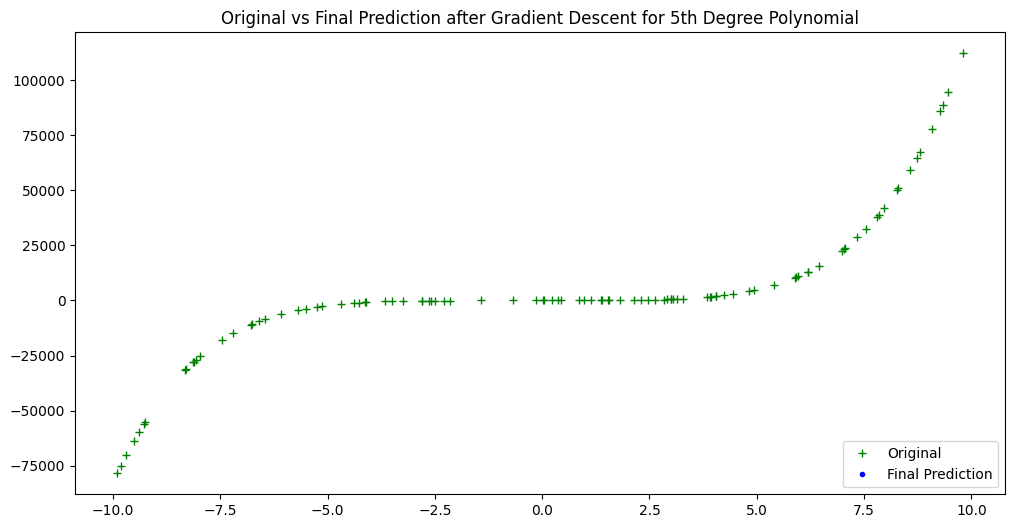

Final Coefficients predicted: (nan, nan, nan, nan, nan, nan)
Original Coefficients: [1, 2, 3, 4, 5, 6]


In [54]:
# Initial coefficients for the 5th degree polynomial
rand_coeffs = [0] * 6  # Example: initial coefficients [a5, a4, a3, a2, a1, a0]

# Perform gradient descent
GD_5th = gradient_descent_5th(30000, 0.0003)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+', label='Original')
plt.plot(xs, GD_5th[2], 'b.', label='Final Prediction')
plt.title('Original vs Final Prediction after Gradient Descent for 5th Degree Polynomial')
plt.legend(loc="lower right")
plt.show()

print(f"Final Coefficients predicted: {GD_5th[1]}")
print(f"Original Coefficients: {coeffs}")


## **Additional Critical Thinking Questions**

1. You are doing full batch gradient descent using the entire training set. Is it necessary to shuffle the training data? Explain your
answer.

2. You would like to train a dog/cat image classifier using mini-batch gradient
descent. You have already split your dataset into train, dev and test sets. The classes
are balanced. You realize that within the training set, the images are ordered in such a
way that all the dog images come first and all the cat images come after. A friend tells
you: ”you absolutely need to shuffle your training set before the training procedure.”
Is your friend right? Explain.

1A)  No, it is not necessary to shuffle the training data when using full batch gradient descent. This is because full batch gradient descent calculates the gradient of the entire dataset in each iteration, meaning the gradient is based on the complete training set. Since every data point is considered at once, the order in which they are presented does not affect the calculation. Therefore, shuffling the data does not impact the result, and the algorithm will converge to the same minima regardless of the data order.




2A)   Yes, it is necessary to shuffle the training set before using mini-batch gradient descent. In mini-batch gradient descent, the training data is divided into smaller batches, and the gradient is computed for each batch. If the training set is ordered with all the dog images first and all the cat images after, each mini-batch may contain only one class, leading to biased gradient updates. This can cause the model to learn in a skewed manner, leading to poor performance. Shuffling ensures that each mini-batch contains a mix of both classes, allowing the model to learn more effectively from diverse data.








